In [49]:
from gym_sepsis.envs.sepsis_env_modified import SepsisEnv
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import datetime
import os

# -------------------------
# Device setup
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 8289
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)



Using device: cpu


In [50]:
# -------------------------
# Environment setup
# -------------------------
env = SepsisEnv()

env.seed(SEED)
env.action_space.seed(SEED)

reset_output = env.reset()
if isinstance(reset_output, tuple):
    state = reset_output[0]
else:
    state = reset_output
state = np.array(state).flatten()

state_size = len(state)
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)


State size: 46
Action size: 24


In [51]:
# obs = env.reset()
# done = False
# while not done:
#     action = env.action_space.sample()
#     obs, reward, done, info = env.step(0)
#     print(reward)

In [52]:
# # -------------------------
# # Q-network (shared by online and target)
# # -------------------------
# class QNetwork(nn.Module):
#     def __init__(self, state_size, action_size, layers=3, hidden=128):
#         super(QNetwork, self).__init__()
#         self.fc_in = nn.Linear(state_size, hidden)
#         self.fc = nn.ModuleList()
#         for _ in range(layers):
#             self.fc.append(nn.Linear(hidden, hidden))
#         self.fc_out = nn.Linear(hidden, action_size)

#     def forward(self, x):
#         x = torch.relu(self.fc_in(x))
#         for layer in self.fc:
#             x = torch.relu(layer(x))
#         return self.fc_out(x)


In [53]:
# -------------------------
# Dueling Q-Network
# -------------------------
class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size, layers=3, hidden=128):
        super(DuelingQNetwork, self).__init__()
        self.fc_in = nn.Linear(state_size, hidden)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(layers)])

        # Separate streams for value and advantage
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_size)
        )

        self._log_adv_scale = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        # Shared feature extraction
        x = torch.relu(self.fc_in(x))
        for layer in self.hidden_layers:
            x = torch.relu(layer(x))

        # Separate value and advantage computation
        value = self.value_stream(x)
        advantage = self.advantage_stream(x)

        adv_mean = advantage.mean(dim=1, keepdim=True)
        adv_std  = advantage.std(dim=1, keepdim=True).clamp_min(1e-2)  # floor avoids blow-ups
        adv_norm = (advantage - adv_mean) / adv_std

        adv_scale = F.softplus(self._log_adv_scale) + 1e-3  # keep positive, ~1.0 initially
        

        # Combine streams: Q(s,a) = V(s) + A(s,a)
        q_values = value + adv_scale * adv_norm
        return q_values


In [54]:
# -------------------------
# Hyperparameters
# -------------------------
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.005
epsilon_decay = 0.995
lr = 1e-4
batch_size = 128
memory_size = 20000
num_episodes = 8000
target_update_freq = 100
eval_episodes = 2000  # for evaluation

time_stamp = datetime.datetime.now().timestamp().__round__()
unique_id = str(time_stamp)
save_path = f"policies/policy_net_{unique_id}.pth"


In [55]:
# -------------------------
# Initialize networks, optimizer, memory
# -------------------------
policy_net = DuelingQNetwork(state_size, action_size).to(device)
target_net = DuelingQNetwork(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr, eps=1e-4)
torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
loss_fn = nn.HuberLoss()
memory = deque(maxlen=memory_size)


In [56]:
# -------------------------
# Helper functions
# -------------------------
def get_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return torch.argmax(q_values).item()

# -------------------------
# Replay function (Dueling Double DQN)
# -------------------------
def replay():
    if len(memory) < batch_size:
        return None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # -------------------------
    # Compute current Q-values
    # -------------------------
    q_values = policy_net(states).gather(1, actions)

    # -------------------------
    # Double DQN target
    # -------------------------
    with torch.no_grad():
        # Select best actions according to online (policy) network
        next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
        # Evaluate those actions using the target network (dueling version)
        next_q_values = target_net(next_states).gather(1, next_actions)
        # Compute target Q-values
        target_q = rewards + (gamma * next_q_values * (1 - dones))

    # -------------------------
    # Compute loss and optimize
    # -------------------------
    loss = loss_fn(q_values, target_q)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
    optimizer.step()

    return loss.item()



In [57]:
# -------------------------
# Training loop
# -------------------------
reward_history, loss_history, episode_length = [], [], []
epsilon_history, action_counts = [], np.zeros(action_size, dtype=int)

for episode in range(num_episodes):
    reset_output = env.reset()
    state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
    state = np.array(state).flatten()
    done, total_reward, steps = False, 0, 0
    episode_losses = []

    while not done:
        action = get_action(state, epsilon)
        step_output = env.step(action)
        if len(step_output) == 5:
            next_state, reward, terminated, truncated, info = step_output
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_output
        next_state = np.array(next_state).flatten()

        memory.append((state, action, reward, next_state, float(done)))
        state = next_state
        total_reward += reward
        steps += 1
        action_counts[action] += 1

        loss_val = replay()
        if loss_val is not None:
            episode_losses.append(loss_val)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    reward_history.append(total_reward)
    epsilon_history.append(epsilon)
    episode_length.append(steps)
    loss_history.append(np.mean(episode_losses) if episode_losses else 0)

    print("Episode {}/{} | Reward: {:.2f} | Steps: {} | Eps: {:.3f}".format(
        episode+1, num_episodes, total_reward, steps, epsilon))

# Save trained policy
torch.save(policy_net.state_dict(), save_path)
print("Saved trained policy to '{}'".format(save_path))


Episode 1/8000 | Reward: 4.55 | Steps: 10 | Eps: 0.995
Episode 2/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.990
Episode 3/8000 | Reward: 4.55 | Steps: 10 | Eps: 0.985
Episode 4/8000 | Reward: -5.90 | Steps: 9 | Eps: 0.980
Episode 5/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.975
Episode 6/8000 | Reward: 4.55 | Steps: 10 | Eps: 0.970
Episode 7/8000 | Reward: 4.55 | Steps: 10 | Eps: 0.966
Episode 8/8000 | Reward: 4.65 | Steps: 8 | Eps: 0.961
Episode 9/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.956
Episode 10/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.951
Episode 11/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.946
Episode 12/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.942
Episode 13/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.937
Episode 14/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.932
Episode 15/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.928
Episode 16/8000 | Reward: 4.60 | Steps: 9 | Eps: 0.923
Episode 17/8000 | Reward: 4.55 | Steps: 10 | Eps: 0.918
Episode 18/8000 | Reward: 4.55 | Steps: 10 | Eps: 0.914
Episode 19/8

In [58]:
# -------------------------
# Evaluation (ε = 0)
# -------------------------
def evaluate_policy(env, model, episodes=20):
    rewards, lengths = [], []
    action_counts_eval = np.zeros(action_size, dtype=int)

    model.eval()
    with torch.no_grad():
        for ep in range(episodes):
            reset_output = env.reset()
            state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
            state = np.array(state).flatten()
            done, total_reward, steps = False, 0, 0

            while not done:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = model(state_t)
                action = torch.argmax(q_values).item()

                step_output = env.step(action)
                if len(step_output) == 5:
                    next_state, reward, terminated, truncated, info = step_output
                    done = terminated or truncated
                else:
                    next_state, reward, done, info = step_output

                next_state = np.array(next_state).flatten()
                state = next_state
                total_reward += reward
                steps += 1
                action_counts_eval[action] += 1

            rewards.append(total_reward)
            lengths.append(steps)
            print("Eval Episode {}/{} | Reward: {:.2f} | Steps: {}".format(ep+1, episodes, total_reward, steps))

    return np.mean(rewards), np.std(rewards), np.mean(lengths), np.std(lengths), action_counts_eval

mean_r, std_r, mean_l, std_l, eval_actions = evaluate_policy(env, policy_net, episodes=eval_episodes)
print("\nEvaluation over {} episodes:".format(eval_episodes))
print("Avg Reward: {:.2f} ± {:.2f}".format(mean_r, std_r))
print("Avg Length: {:.2f} ± {:.2f}".format(mean_l, std_l))


Eval Episode 1/2000 | Reward: 4.60 | Steps: 9
Eval Episode 2/2000 | Reward: 4.60 | Steps: 9
Eval Episode 3/2000 | Reward: 4.55 | Steps: 10
Eval Episode 4/2000 | Reward: 4.75 | Steps: 6
Eval Episode 5/2000 | Reward: 4.60 | Steps: 9
Eval Episode 6/2000 | Reward: 4.60 | Steps: 9
Eval Episode 7/2000 | Reward: 4.60 | Steps: 9
Eval Episode 8/2000 | Reward: 4.60 | Steps: 9
Eval Episode 9/2000 | Reward: 4.75 | Steps: 6
Eval Episode 10/2000 | Reward: 4.60 | Steps: 9
Eval Episode 11/2000 | Reward: 4.60 | Steps: 9
Eval Episode 12/2000 | Reward: 4.60 | Steps: 9
Eval Episode 13/2000 | Reward: 4.60 | Steps: 9
Eval Episode 14/2000 | Reward: 4.65 | Steps: 8
Eval Episode 15/2000 | Reward: 4.60 | Steps: 9
Eval Episode 16/2000 | Reward: 4.70 | Steps: 7
Eval Episode 17/2000 | Reward: 4.55 | Steps: 10
Eval Episode 18/2000 | Reward: 4.55 | Steps: 10
Eval Episode 19/2000 | Reward: 4.65 | Steps: 8
Eval Episode 20/2000 | Reward: 4.65 | Steps: 8
Eval Episode 21/2000 | Reward: 4.55 | Steps: 10
Eval Episode 22/20

Directory 'plots/1761867031' created successfully.


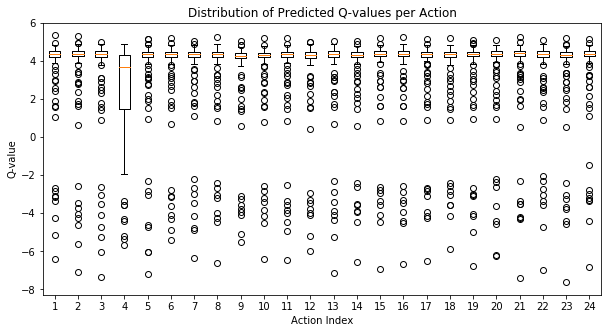

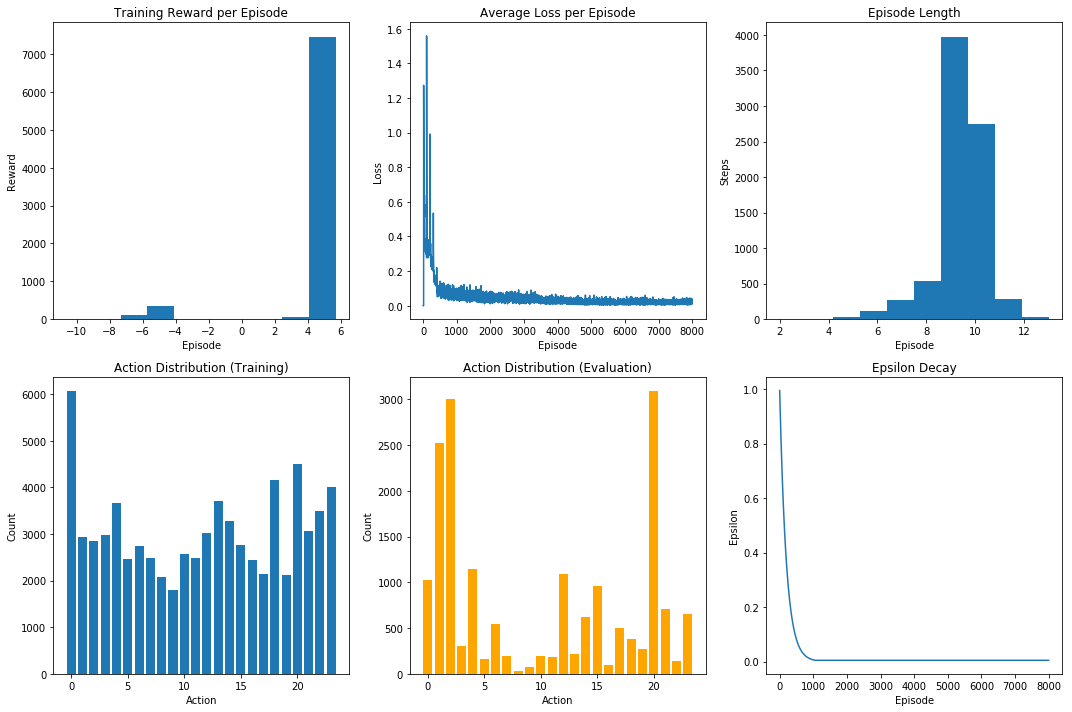

In [59]:
# -------------------------
# Visualizations (optional)
# -------------------------
directory_name = f"plots/{unique_id}"
try:
    os.mkdir(directory_name)
    print(f"Directory '{directory_name}' created successfully.")
except FileExistsError:
    print(f"Directory '{directory_name}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

def visualize_q_distribution(model, n_samples=200):
    sampled_states = []
    for _ in range(n_samples):
        reset_output = env.reset()
        s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        sampled_states.append(np.array(s).flatten())
    states_t = torch.FloatTensor(np.vstack(sampled_states)).to(device)
    with torch.no_grad():
        q_vals = model(states_t).cpu().numpy()
    plt.figure(figsize=(10,5))
    plt.boxplot(q_vals)
    plt.title("Distribution of Predicted Q-values per Action")
    plt.xlabel("Action Index")
    plt.ylabel("Q-value")
    plt.savefig(f"plots/{unique_id}/q_values.png")
    plt.show()
    plt.close()

visualize_q_distribution(policy_net)

plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
plt.hist(reward_history)
plt.title("Training Reward per Episode")
plt.xlabel("Episode"); plt.ylabel("Reward")

plt.subplot(2,3,2)
plt.plot(loss_history)
plt.title("Average Loss per Episode")
plt.xlabel("Episode"); plt.ylabel("Loss")

plt.subplot(2,3,3)
plt.hist(episode_length)
plt.title("Episode Length")
plt.xlabel("Episode"); plt.ylabel("Steps")

plt.subplot(2,3,4)
plt.bar(np.arange(action_size), action_counts)
plt.title("Action Distribution (Training)")
plt.xlabel("Action"); plt.ylabel("Count")

plt.subplot(2,3,5)
plt.bar(np.arange(action_size), eval_actions, color='orange')
plt.title("Action Distribution (Evaluation)")
plt.xlabel("Action"); plt.ylabel("Count")

plt.subplot(2,3,6)
plt.plot(epsilon_history)
plt.title("Epsilon Decay")
plt.xlabel("Episode"); plt.ylabel("Epsilon")

plt.tight_layout()
plt.savefig(f"plots/{unique_id}/training_plots.png")
plt.show()
plt.close()


In [60]:

reset_output = env.reset()
s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
s = np.array(state).flatten()
s = torch.FloatTensor(state).to(device)
with torch.no_grad():
    shared = torch.relu(policy_net.fc_in(s))
    for layer in policy_net.hidden_layers:
        shared = torch.relu(layer(shared))
    value = policy_net.value_stream(shared)
    adv = policy_net.advantage_stream(shared)
print("Value:", value)
print("Advantage:", adv)

Value: tensor([4.5563])
Advantage: tensor([-0.0030,  0.0014, -0.0087, -0.0504,  0.0009, -0.0014, -0.0030, -0.0021,
        -0.0045, -0.0054, -0.0062, -0.0055, -0.0049, -0.0030, -0.0034, -0.0059,
        -0.0029, -0.0073, -0.0005, -0.0070, -0.0010, -0.0062, -0.0058, -0.0052])


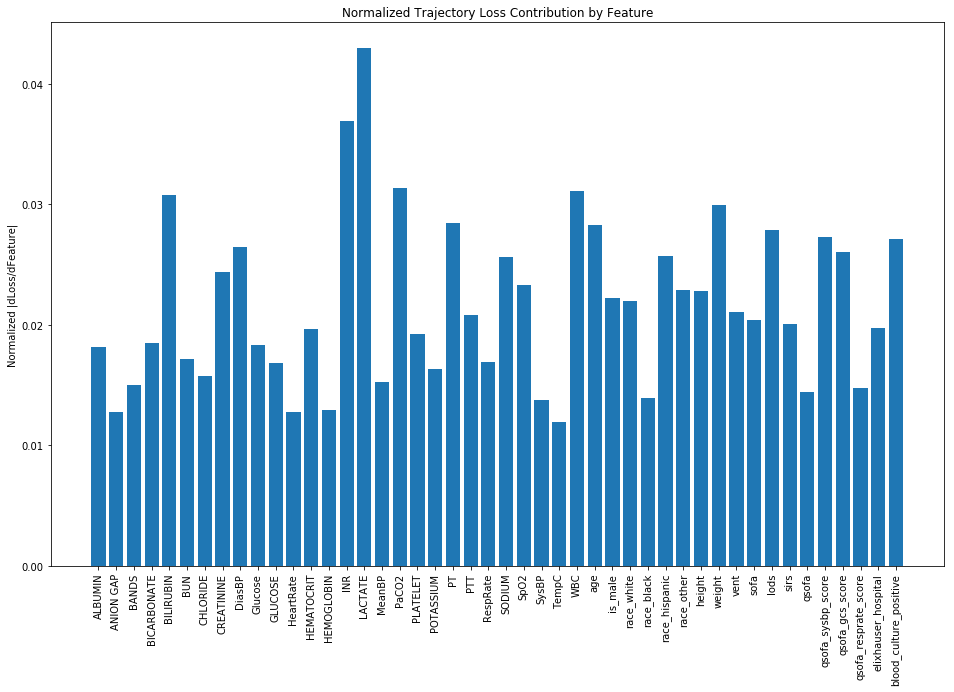

In [61]:
# -------------------------
# Feature gradient importance (optional)
# -------------------------
def compute_feature_loss_importance(model, memory, batch_size=256):
    if len(memory) < batch_size:
        print("Not enough samples in memory.")
        return None, None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    states.requires_grad = True

    q_values = policy_net(states).gather(1, actions)
    next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
    next_q_values = target_net(next_states).gather(1, next_actions).detach()
    target_q = rewards + (gamma * next_q_values * (1 - dones))

    loss = (q_values - target_q).pow(2).mean()
    loss.backward(retain_graph=True)

    grad_magnitudes = states.grad.abs().mean(dim=0).cpu().numpy()
    norm_grad = grad_magnitudes / (grad_magnitudes.sum() + 1e-8)

    feature_idx = np.arange(len(norm_grad))
    plt.figure(figsize=(16,10))
    feature_names = env.feature_names if hasattr(env, 'feature_names') else ["f{}".format(i) for i in range(state_size)]
    plt.bar(feature_names[0:46], norm_grad)
    plt.xticks(rotation=90)
    plt.title("Normalized Trajectory Loss Contribution by Feature")
    plt.ylabel("Normalized |dLoss/dFeature|")
    plt.savefig(f"plots/{unique_id}/loss_by_feature.png")
    plt.show()
    plt.close()

    return grad_magnitudes, norm_grad

# Run after training:
grad_mags, norm_grad = compute_feature_loss_importance(policy_net, memory)


In [62]:
# # -------------------------
# # === XRL MODULE 1: Policy Distillation -> Decision Tree
# # -------------------------
# from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
# from sklearn.metrics import accuracy_score

# directory_name = f"trees/{unique_id}"
# try:
#     os.mkdir(directory_name)
#     print(f"Directory '{directory_name}' created successfully.")
# except FileExistsError:
#     print(f"Directory '{directory_name}' already exists.")
# except Exception as e:
#     print(f"An error occurred: {e}")

# def distill_policy_to_tree(model, env, n_samples=3000, max_depth=4):
#     model.eval()
#     X, y = [], []

#     for _ in range(n_samples):
#         reset_output = env.reset()
#         s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
#         s = np.array(s).flatten()
#         X.append(s)

#         with torch.no_grad():
#             s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
#             q_vals = model(s_t)
#             action = torch.argmax(q_vals).item()
#             y.append(action)

#     X = np.array(X)
#     y = np.array(y)

#     tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
#     tree.fit(X, y)

#     fidelity = accuracy_score(y, tree.predict(X))
#     print("Distillation complete - Tree fidelity to policy: {:.2f}%".format(fidelity * 100))

#     with open(f"trees/{unique_id}/tree_fidelity.txt", 'w', encoding='utf-8') as file:
#         file.write("Distillation complete - Tree fidelity to policy: {:.2f}%".format(fidelity * 100))

#     plt.figure(figsize=(64, 40))
#     feature_names = getattr(env, "feature_names", ["f{}".format(i) for i in range(X.shape[1])])
#     plot_tree(tree, feature_names=feature_names[0:46],
#               class_names=[str(i) for i in range(env.action_space.n)], filled=True)
#     plt.title("Decision Tree Surrogate for Policy")
#     plt.savefig(f"plots/{unique_id}/decision_tree.png")
#     plt.show()
#     plt.close()

#     print(export_text(tree, feature_names=feature_names[0:46]))
#     return tree

# policy_tree = distill_policy_to_tree(policy_net, env, n_samples=3000, max_depth=4)

# # Save the tree if desired (pickle)
# try:
#     import pickle
#     with open(f"trees/{unique_id}/policy_tree.pkl", "wb") as f:
#         pickle.dump(policy_tree, f)
#     print("Saved tree as 'policy_tree.pkl'")
# except Exception as e:
#     print("Could not save tree: {}".format(e))


In [63]:
# # -------------------------
# # === XRL MODULE 1: Policy Distillation -> Random Forest with Soft Targets & Per-Action PDPs
# # -------------------------
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import accuracy_score, r2_score
# from sklearn.inspection import PartialDependenceDisplay
# import matplotlib.pyplot as plt
# import numpy as np
# import os
# import torch

# directory_name = f"trees/{unique_id}"
# try:
#     os.mkdir(directory_name)
#     print(f"Directory '{directory_name}' created successfully.")
# except FileExistsError:
#     print(f"Directory '{directory_name}' already exists.")
# except Exception as e:
#     print(f"An error occurred: {e}")


# def sample_policy_states(env, model, n_steps=5000):
#     """Collect realistic state samples by rolling out the trained policy."""
#     states = []
#     reset_output = env.reset()
#     s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
#     s = np.array(s).flatten()
#     done = False

#     while len(states) < n_steps:
#         states.append(s)
#         with torch.no_grad():
#             s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
#             q_vals = model(s_t)
#             a = torch.argmax(q_vals).item()
#         step_output = env.step(a)
#         if len(step_output) == 5:
#             next_state, reward, terminated, truncated, info = step_output
#             done = terminated or truncated
#         else:
#             next_state, reward, done, info = step_output
#         s = np.array(next_state).flatten()
#         if done:
#             reset_output = env.reset()
#             s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
#             s = np.array(s).flatten()
#             done = False
#     return np.array(states)


# def distill_policy_to_forest(model, env, n_samples=5000, max_depth=6,
#                              use_feature_selection=True, top_pdp_features=3):
#     """Distill policy into a RandomForestRegressor trained on Q-values, with per-action PDPs."""
#     model.eval()
#     print("\n--- Sampling states from policy rollouts ---")
#     X = sample_policy_states(env, model, n_steps=n_samples)

#     print("Computing soft Q-targets from trained policy...")
#     Y = []
#     with torch.no_grad():
#         for s in X:
#             s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
#             q_vals = model(s_t).cpu().numpy().flatten()
#             Y.append(q_vals)
#     Y = np.array(Y)

#     # --- Optional feature selection using gradient importance ---
#     feature_names = getattr(env, "feature_names",
#                             [f"f{i}" for i in range(X.shape[1])])
#     if use_feature_selection and 'norm_grad' in globals() and norm_grad is not None:
#         top_k = 15 if X.shape[1] > 15 else X.shape[1]
#         important_idx = np.argsort(norm_grad)[-top_k:]
#         X = X[:, important_idx]
#         selected_features = [feature_names[i] for i in important_idx]
#         print(f"Using top-{top_k} features based on gradient importance.")
#     else:
#         selected_features = feature_names

#     print("\n--- Training Random Forest on Q-value targets ---")
#     forest = RandomForestRegressor(
#         n_estimators=100,
#         max_depth=max_depth,
#         n_jobs=-1,
#         random_state=42
#     )
#     forest.fit(X, Y)

#     # --- Compute fidelity and R² metrics ---
#     preds = forest.predict(X)
#     fidelity = np.mean(np.argmax(preds, axis=1) == np.argmax(Y, axis=1))
#     r2 = r2_score(Y.flatten(), preds.flatten())
#     print(f"\nDistillation complete.")
#     print(f"Fidelity (argmax match): {fidelity*100:.2f}%")
#     print(f"R² on Q-values: {r2:.3f}")

#     # --- Save fidelity results ---
#     with open(f"trees/{unique_id}/forest_fidelity.txt", 'w', encoding='utf-8') as file:
#         file.write(f"Random Forest Distillation Results\n")
#         file.write(f"Fidelity (argmax match): {fidelity*100:.2f}%\n")
#         file.write(f"R² on Q-values: {r2:.3f}\n")

#     # --- Global feature importance ---
#     importances = forest.feature_importances_
#     sorted_idx = np.argsort(importances)[::-1]
#     plt.figure(figsize=(12, 6))
#     plt.bar(np.array(selected_features)[sorted_idx],
#             importances[sorted_idx], color='skyblue')
#     plt.xticks(rotation=90)
#     plt.title("Global Feature Importance (Random Forest)")
#     plt.ylabel("Importance")
#     plt.tight_layout()
#     plt.savefig(f"plots/{unique_id}/forest_feature_importance.png")
#     plt.show()
#     plt.close()

#     # --- Partial Dependence Plots (PDPs) for top features, per action ---
#     try:
#         print("\n--- Generating Partial Dependence Plots (PDPs) per Action ---")
#         top_features = [selected_features[i] for i in sorted_idx[:top_pdp_features]]
#         n_actions = Y.shape[1]

#         for action in range(n_actions):
#             print(f"Creating PDPs for Action {action}...")
#             fig, ax = plt.subplots(figsize=(6 * top_pdp_features, 5))
#             PartialDependenceDisplay.from_estimator(
#                 forest,
#                 X,
#                 features=list(range(min(top_pdp_features, len(selected_features)))),
#                 feature_names=selected_features,
#                 target=action,
#                 ax=ax
#             )
#             plt.suptitle(f"Partial Dependence (Action {action} Q-value)")
#             plt.tight_layout()
#             plt.savefig(f"plots/{unique_id}/forest_pdp_action{action}.png")
#             plt.close()
#     except Exception as e:
#         print(f"Could not generate PDPs: {e}")

#     # --- Save forest model ---
#     import pickle
#     with open(f"trees/{unique_id}/policy_forest.pkl", "wb") as f:
#         pickle.dump(forest, f)
#     print("Saved distilled forest as 'policy_forest.pkl'")

#     return forest, fidelity, r2


# # Run distillation
# policy_forest, fidelity, r2 = distill_policy_to_forest(
#     policy_net, env, n_samples=5000, max_depth=6,
#     use_feature_selection=True, top_pdp_features=3)



--- Sampling states from policy rollouts ---
Computing soft Q-targets from trained policy...
Using top-15 features based on gradient importance.

--- Training Random Forest on Q-value targets ---

--- Baseline RF surrogate ---
R² (overall): 0.878
Argmax fidelity: 26.82%
Per-action R²: [0.888 0.884 0.893 0.774 0.891 0.88  0.886 0.883 0.877 0.88  0.881 0.881
 0.88  0.883 0.886 0.886 0.88  0.882 0.889 0.892 0.876 0.886 0.885 0.884]

Margin-conditioned fidelity:
  margin ≥ 0.00: 26.8%  (n=5000)
  margin ≥ 0.02: 32.9%  (n=2248)
  margin ≥ 0.05: 44.0%  (n=757)
  margin ≥ 0.10: 51.7%  (n=240)
  margin ≥ 0.20: 53.1%  (n=96)

Mean prediction bias per action: [0.001 0.001 0.002 0.003 0.002 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.002 0.001]


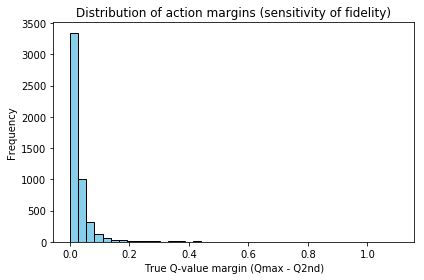


Fidelity (argmax match): 26.82% | R²: 0.880

--- Visualizing one best-performing tree per action with dtreeviz ---
Action 0: selected tree #35 with R²=0.872
Saved dtreeviz visualization for Action 0 → plots/1761867031/dtree_plots/dtreeviz_best_tree_action0.svg
Action 1: selected tree #35 with R²=0.867
Saved dtreeviz visualization for Action 1 → plots/1761867031/dtree_plots/dtreeviz_best_tree_action1.svg
Action 2: selected tree #35 with R²=0.878
Saved dtreeviz visualization for Action 2 → plots/1761867031/dtree_plots/dtreeviz_best_tree_action2.svg
Action 3: selected tree #1045 with R²=0.744
Saved dtreeviz visualization for Action 3 → plots/1761867031/dtree_plots/dtreeviz_best_tree_action3.svg
Action 4: selected tree #35 with R²=0.875
Saved dtreeviz visualization for Action 4 → plots/1761867031/dtree_plots/dtreeviz_best_tree_action4.svg
Action 5: selected tree #35 with R²=0.865
Saved dtreeviz visualization for Action 5 → plots/1761867031/dtree_plots/dtreeviz_best_tree_action5.svg
Action

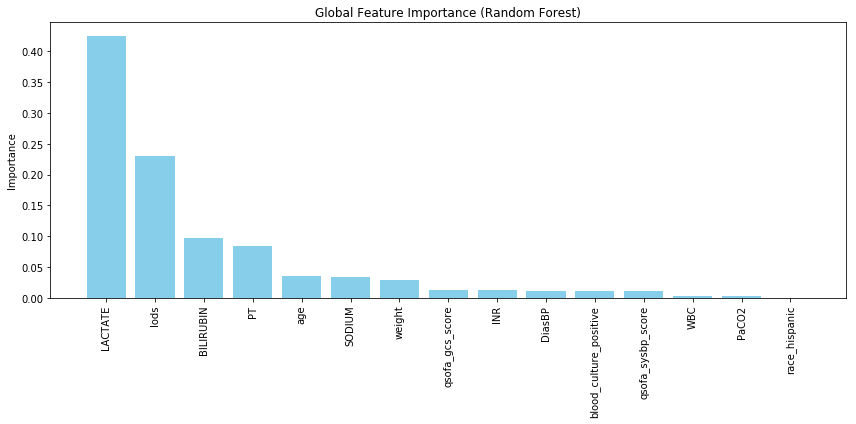


--- Generating Partial Dependence Plots (legacy-safe mode) ---
Creating PDPs for Action 0...


A Bunch will be returned in place of 'predictions' from version 1.1 (renaming of 0.26) with partial dependence results accessible via the 'average' key. In the meantime, pass kind='average' to get the future behaviour.


Creating PDPs for Action 1...
Creating PDPs for Action 2...
Creating PDPs for Action 3...
Creating PDPs for Action 4...
Creating PDPs for Action 5...
Creating PDPs for Action 6...
Creating PDPs for Action 7...
Creating PDPs for Action 8...
Creating PDPs for Action 9...
Creating PDPs for Action 10...
Creating PDPs for Action 11...
Creating PDPs for Action 12...
Creating PDPs for Action 13...
Creating PDPs for Action 14...
Creating PDPs for Action 15...
Creating PDPs for Action 16...
Creating PDPs for Action 17...
Creating PDPs for Action 18...
Creating PDPs for Action 19...
Creating PDPs for Action 20...
Creating PDPs for Action 21...
Creating PDPs for Action 22...
Creating PDPs for Action 23...
PDP generation complete.

--- Computing SHAP values (TreeExplainer) ---

--- Generating per-action SHAP summary plots ---
SHAP plots saved successfully.
Saved distilled forest as 'policy_forest.pkl'


In [64]:
# === XRL MODULE 1: Policy Distillation -> Random Forest + PDP (legacy) + SHAP
# Compatible with Python 3.6.8 / scikit-learn <= 0.22
# -------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import shap
from dtreeviz.trees import dtreeviz
import pandas as pd


directory_name = f"trees/{unique_id}"
os.makedirs(directory_name, exist_ok=True)
os.makedirs(f"plots/{unique_id}/shap_summary_plots", exist_ok=True)
os.makedirs(f"plots/{unique_id}/forest_pdp_plots", exist_ok=True)
os.makedirs(f"plots/{unique_id}/dtree_plots", exist_ok=True)


def sample_policy_states(env, model, n_steps=5000):
    """Collect realistic state samples by rolling out the trained policy."""
    states = []
    reset_output = env.reset()
    s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
    s = np.array(s).flatten()
    done = False

    while len(states) < n_steps:
        states.append(s)
        with torch.no_grad():
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q_vals = model(s_t)
            a = torch.argmax(q_vals).item()
        step_output = env.step(a)
        if len(step_output) == 5:
            next_state, reward, terminated, truncated, info = step_output
            done = terminated or truncated
        else:
            next_state, reward, done, info = step_output
        s = np.array(next_state).flatten()
        if done:
            reset_output = env.reset()
            s = reset_output[0] if isinstance(reset_output, tuple) else reset_output
            s = np.array(s).flatten()
            done = False
    return np.array(states)


# ==============================================
# Fidelity diagnostics for RandomForest surrogate
# ==============================================

def evaluate_fidelity_diagnostics(forest, X, Y, label=""):
    """
    Diagnose RandomForest fidelity & give tuning hints.
    Should be called right after forest.fit(X, Y).
    """

    preds = forest.predict(X)
    n_actions = Y.shape[1]

    # ----- 1. Overall R² and fidelity -----
    r2 = r2_score(Y, preds, multioutput='variance_weighted')
    fidelity = (preds.argmax(1) == Y.argmax(1)).mean()
    print(f"\n--- {label or 'Forest'} ---")
    print(f"R² (overall): {r2:.3f}")
    print(f"Argmax fidelity: {fidelity*100:.2f}%")

    # ----- 2. Per-action R² -----
    r2s = [r2_score(Y[:,a], preds[:,a]) for a in range(n_actions)]
    print("Per-action R²:", np.round(r2s, 3))

    # ----- 3. Margin-conditioned fidelity -----
    top = Y.max(1)
    second = np.partition(Y, -2, axis=1)[:, -2]
    margin = top - second
    thresholds = [0.0, 0.02, 0.05, 0.1, 0.2]
    print("\nMargin-conditioned fidelity:")
    for thr in thresholds:
        mask = margin >= thr
        if mask.any():
            subfid = (preds.argmax(1)[mask] == Y.argmax(1)[mask]).mean()
            print(f"  margin ≥ {thr:.2f}: {subfid*100:.1f}%  (n={mask.sum()})")

    # ----- 4. Per-action bias check -----
    bias = preds.mean(axis=0) - Y.mean(axis=0)
    print("\nMean prediction bias per action:", np.round(bias, 3))

    # ----- 5. Visual diagnostic -----
    plt.figure(figsize=(6,4))
    plt.hist(margin, bins=40, color='skyblue', edgecolor='k')
    plt.xlabel("True Q-value margin (Qmax - Q2nd)")
    plt.ylabel("Frequency")
    plt.title("Distribution of action margins (sensitivity of fidelity)")
    plt.tight_layout()
    plt.show()




def distill_policy_to_forest(model, env, n_samples=5000, max_depth=20,
                             use_feature_selection=True, top_pdp_features=3):
    """Distill policy into a RandomForestRegressor trained on Q-values, with PDP & SHAP."""
    model.eval()
    print("\n--- Sampling states from policy rollouts ---")
    X = sample_policy_states(env, model, n_steps=n_samples)

    print("Computing soft Q-targets from trained policy...")
    Y = []
    with torch.no_grad():
        for s in X:
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q_vals = model(s_t).cpu().numpy().flatten()
            Y.append(q_vals)
    Y = np.array(Y)

    feature_names = getattr(env, "feature_names",
                            [f"f{i}" for i in range(X.shape[1])])
    if use_feature_selection and 'norm_grad' in globals() and norm_grad is not None:
        top_k = 15 if X.shape[1] > 15 else X.shape[1]
        important_idx = np.argsort(norm_grad)[-top_k:]
        X = X[:, important_idx]
        selected_features = [feature_names[i] for i in important_idx]
        print(f"Using top-{top_k} features based on gradient importance.")
    else:
        selected_features = feature_names

    print("\n--- Training Random Forest on Q-value targets ---")
    forest = RandomForestRegressor(
        n_estimators=1200, max_depth=max_depth, min_samples_leaf=10, n_jobs=-1, random_state=8289
    )
    forest.fit(X, Y)

    # depths = [10, 15, 20, 30, None]
    # leaves = [50, 20, 10]
    # results = []

    # for d in depths:
    #     for leaf in leaves:
    #         forest = RandomForestRegressor(
    #             n_estimators=800,
    #             max_depth=d,
    #             min_samples_leaf=leaf,
    #             random_state=42,
    #             n_jobs=-1
    #         )
    #         forest.fit(X, Y)
    #         preds = forest.predict(X)
    #         r2 = r2_score(Y, preds, multioutput='variance_weighted')
    #         fidelity = (preds.argmax(1) == Y.argmax(1)).mean()
    #         results.append((d, leaf, r2, fidelity))
    #         print(f"Depth={d}, Leaf={leaf}: R²={r2:.3f}, Fidelity={fidelity*100:.2f}%")


    evaluate_fidelity_diagnostics(forest, X, Y, label="Baseline RF surrogate")

    preds = forest.predict(X)
    fidelity = np.mean(np.argmax(preds, axis=1) == np.argmax(Y, axis=1))
    r2 = r2_score(Y.flatten(), preds.flatten())
    print(f"\nFidelity (argmax match): {fidelity*100:.2f}% | R²: {r2:.3f}")

    # --- Save fidelity results ---
    with open(f"trees/{unique_id}/forest_fidelity.txt", 'w', encoding='utf-8') as f:
        f.write("Random Forest Distillation Results\n")
        f.write(f"Fidelity (argmax match): {fidelity*100:.2f}%\n")
        f.write(f"R² on Q-values: {r2:.3f}\n")


    # --- Visualize one best decision tree per action using dtreeviz (Python 3.6.8 compatible) ---
    try:
        print("\n--- Visualizing one best-performing tree per action with dtreeviz ---")
        feature_names_viz = selected_features
        X_df = pd.DataFrame(X, columns=feature_names_viz)
        n_actions = Y.shape[1] if Y.ndim > 1 else 1

        for action_idx in range(n_actions):
            y_single = Y[:, action_idx]

            # Compute individual tree R² for this action
            scores = []
            for i, tree in enumerate(forest.estimators_):
                preds = tree.predict(X)
                if preds.ndim > 1:
                    preds = preds[:, action_idx]
                r2_i = r2_score(y_single, preds)
                scores.append(r2_i)

            best_idx = int(np.argmax(scores))
            best_tree = forest.estimators_[best_idx]
            print(f"Action {action_idx}: selected tree #{best_idx} with R²={scores[best_idx]:.3f}")

            viz = dtreeviz(
                best_tree,
                X_df,
                y_single,
                target_name=f"Q(Action {action_idx})",
                feature_names=feature_names_viz,
                title=f"Decision Tree #{best_idx} – Action {action_idx}",
                fancy=True,
                histtype='barstacked',
                scale=1.0
            )

            viz_path = f"plots/{unique_id}/dtree_plots/dtreeviz_best_tree_action{action_idx}.svg"
            viz.save(viz_path)
            print(f"Saved dtreeviz visualization for Action {action_idx} → {viz_path}")

        print("All dtreeviz visualizations complete.")

    except ImportError:
        print("dtreeviz not installed. Install with:")
        print("pip install dtreeviz==1.1.5 graphviz pydotplus")
    except Exception as e:
        print(f"Could not generate dtreeviz visualizations: {e}")


    # --- Summarize feature usage frequency across best trees (structure-level interpretability) ---
    try:
        print("\n--- Summarizing feature usage frequency across best trees ---")
        n_actions = Y.shape[1] if Y.ndim > 1 else 1   # ensure defined

        feature_usage_counts = {feat: 0 for feat in selected_features}
        action_best_trees = []

        for action_idx in range(n_actions):
            y_single = Y[:, action_idx]
            scores = []
            for i, tree in enumerate(forest.estimators_):
                preds = tree.predict(X)
                if preds.ndim > 1:
                    preds = preds[:, action_idx]
                r2_i = r2_score(y_single, preds)
                scores.append(r2_i)

            best_idx = int(np.argmax(scores))
            best_tree = forest.estimators_[best_idx]
            action_best_trees.append(best_tree)

            used_features = best_tree.tree_.feature
            for f_idx in used_features:
                if f_idx >= 0:  # skip leaves
                    feature_usage_counts[selected_features[f_idx]] += 1

        feature_usage_df = pd.DataFrame(
            list(feature_usage_counts.items()),
            columns=["Feature", "UsageCount"]
        ).sort_values("UsageCount", ascending=False)

        print("\nTop features used across best trees:")
        print(feature_usage_df.head(10))

        plt.figure(figsize=(10, 5))
        plt.bar(feature_usage_df["Feature"], feature_usage_df["UsageCount"], color='teal')
        plt.xticks(rotation=90)
        plt.title("Feature Usage Frequency Across Best Trees (All Actions)")
        plt.ylabel("Number of Splits (across trees)")
        plt.tight_layout()
        plt.savefig(f"plots/{unique_id}/feature_usage_best_trees.png")
        plt.close()

        feature_usage_df.to_csv(f"plots/{unique_id}/feature_usage_best_trees.csv", index=False)
        print(f"Feature usage summary saved to plots/{unique_id}/feature_usage_best_trees.png and .csv")

    except Exception as e:
        print(f"Could not summarize feature usage: {e}")





    # --- Global feature importance ---
    importances = forest.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    plt.figure(figsize=(12, 6))
    plt.bar(np.array(selected_features)[sorted_idx],
            importances[sorted_idx], color='skyblue')
    plt.xticks(rotation=90)
    plt.title("Global Feature Importance (Random Forest)")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.savefig(f"plots/{unique_id}/forest_feature_importance.png")
    plt.show()
    plt.close()

    # --- PDPs (fully backward-compatible for sklearn <=0.25) ---
    try:
        print("\n--- Generating Partial Dependence Plots (legacy-safe mode) ---")
        from sklearn.inspection import partial_dependence

        top_features = [selected_features[i] for i in sorted_idx[:top_pdp_features]]
        n_actions = Y.shape[1]

        for action in range(n_actions):
            print(f"Creating PDPs for Action {action}...")
            for feat_name in top_features:
                feat_idx = selected_features.index(feat_name)

                # Call partial_dependence()
                pdp_out = partial_dependence(
                    forest,
                    X,
                    [feat_idx],
                    grid_resolution=80
                )

                # Handle different sklearn versions
                if isinstance(pdp_out, tuple):
                    avg, values = pdp_out  # old sklearn <=0.25
                elif isinstance(pdp_out, dict) or hasattr(pdp_out, "average"):
                    avg = pdp_out["average"]
                    values = pdp_out["values"]
                else:
                    raise TypeError("Unrecognized partial_dependence() output format")

                # Extract results per action
                if isinstance(avg, list) or avg.ndim == 3:
                    yvals = avg[0][action]
                else:
                    yvals = avg[0]

                xvals = values[0]

                # Plot PDP curve
                plt.figure(figsize=(5, 4))
                plt.plot(xvals, yvals, color='C0', lw=2)
                plt.title(f'PDP: {feat_name} → Q(Action {action})')
                plt.xlabel(feat_name)
                plt.ylabel('Partial Dependence')
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(f"plots/{unique_id}/forest_pdp_plots/forest_pdp_action{action}_{feat_name}.png")
                plt.close()



        print("PDP generation complete.")
    except Exception as e:
        print(f"Could not generate PDPs: {e}")



    # --- SHAP value visualizations ---
    try:
        print("\n--- Computing SHAP values (TreeExplainer) ---")
        explainer = shap.TreeExplainer(forest)
        # Use subset for performance
        X_sample = X[:min(1000, len(X))]
        shap_values = explainer.shap_values(X_sample)

        # Global summary (averaged across actions)
        if isinstance(shap_values, list):
            shap_values_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
        else:
            shap_values_mean = np.abs(shap_values)
        shap.summary_plot(shap_values_mean, X_sample,
                          feature_names=selected_features,
                          show=False)
        plt.title("SHAP Summary (Mean |SHAP| across actions)")
        plt.tight_layout()
        plt.savefig(f"plots/{unique_id}/shap_summary_global.png")
        plt.close()

        # Local dependence for top feature, first action
        if isinstance(shap_values, list):
            shap.dependence_plot(0, shap_values[0], X_sample,
                                 feature_names=selected_features,
                                 show=False)
        else:
            shap.dependence_plot(0, shap_values, X_sample,
                                 feature_names=selected_features,
                                 show=False)
        plt.title("SHAP Dependence: Top Feature vs Q(Action 0)")
        plt.tight_layout()
        plt.savefig(f"plots/{unique_id}/shap_dependence_action0.png")
        plt.close()

        # === NEW: Per-Action SHAP Summaries ===
        print("\n--- Generating per-action SHAP summary plots ---")
        if isinstance(shap_values, list):
            n_actions = len(shap_values)
            for action_idx, sv in enumerate(shap_values):
                plt.figure()
                shap.summary_plot(sv, X_sample, feature_names=selected_features,
                                  show=False, max_display=15)
                plt.title(f"SHAP Summary: Action {action_idx} (Q-value)")
                plt.tight_layout()
                plt.savefig(f"plots/{unique_id}/shap_summary_plots/shap_summary_action{action_idx}.png")
                plt.close()
        else:
            print("Single output model: per-action SHAP summaries not applicable.")

        print("SHAP plots saved successfully.")
    except Exception as e:
        print(f"Could not compute SHAP values: {e}")


    # --- Save forest model ---
    import pickle
    with open(f"trees/{unique_id}/policy_forest.pkl", "wb") as f:
        pickle.dump(forest, f)
    print("Saved distilled forest as 'policy_forest.pkl'")

    return forest, fidelity, r2


# Run distillation
policy_forest, fidelity, r2 = distill_policy_to_forest(
    policy_net, env, n_samples=5000, max_depth=10,
    use_feature_selection=True, top_pdp_features=3)

